In [28]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

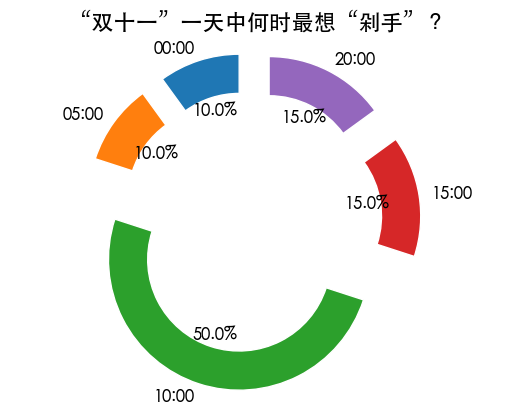

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 时段标签
labels = ["00:00", "05:00", "10:00", "15:00", "20:00"]
# 模拟占比数据（可根据实际需求替换，这里为演示设值），数值仅作示例
sizes = [10, 10, 50, 15, 15]  
# 环形图缺口（让环形更明显），这里统一设 0.3，可调整
explode = [0.3] * len(labels)  

fig, ax = plt.subplots()

# 绘制环形图，wedgeprops 控制环形宽度等样式
ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct="%1.1f%%",  # 显示百分比
    startangle=90,      # 起始角度
    wedgeprops={"width": 0.3, "edgecolor": "white"},  # 环形宽度、边缘颜色
    textprops={"fontsize": 12}  # 文本字体大小
)
ax.set_title("“双十一”一天中何时最想“剁手”？", fontsize=16, fontweight="bold")

# 让饼图保持圆形（避免拉伸变形）
ax.axis("equal")  

plt.show()

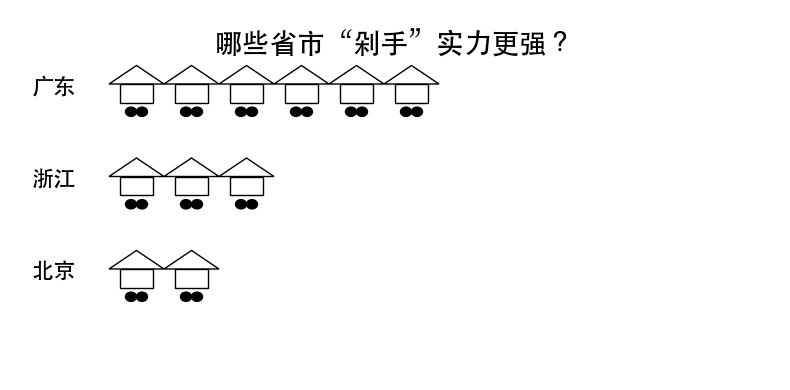

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 数据：省份及对应购物车数量
data = {
    "广东": 6,
    "浙江": 3,
    "北京": 2
}
# 省份坐标（y 轴位置，控制上下排版）
province_y = {
    "广东": 2,
    "浙江": 1,
    "北京": 0
}
# 购物车基础尺寸
cart_width = 0.3
cart_height = 0.2

# 创建画布
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 7)
ax.set_ylim(-1, 3)
ax.axis('off')  # 隐藏坐标轴

# 绘制标题 - 修改了x坐标和对齐方式
ax.text(
    3.5, 2.8, "哪些省市“剁手”实力更强？",  # x坐标从0.5改为3.5（x轴范围是0-7）
    fontsize=20, fontweight='bold',
    ha='center', va='top'  # ha=center保持居中对齐
)

# 定义绘制单个购物车的函数
def draw_cart(x, y):
    """
    在 (x, y) 位置绘制简化购物车图标
    """
    # 购物车筐（矩形）
    cart_basket = patches.Rectangle(
        (x, y), cart_width, cart_height,
        facecolor='none', edgecolor='black'
    )
    ax.add_patch(cart_basket)
    # 购物车把手（多边形模拟）
    cart_handle = patches.Polygon(
        [[x - 0.1, y + cart_height],
         [x + cart_width + 0.1, y + cart_height],
         [x + cart_width / 2, y + cart_height + 0.2]],
        facecolor='none', edgecolor='black'
    )
    ax.add_patch(cart_handle)
    # 购物车轮子（两个小圆）
    wheel1 = patches.Circle((x + 0.1, y - 0.1), 0.05, color='black')
    wheel2 = patches.Circle((x + 0.2, y - 0.1), 0.05, color='black')
    ax.add_patch(wheel1)
    ax.add_patch(wheel2)

# 遍历数据绘制省份名称 + 购物车
for province, count in data.items():
    # 绘制省份文本
    ax.text(
        0.2, province_y[province] + 0.1, 
        province, fontsize=16, fontweight='bold'
    )
    # 循环绘制购物车
    for i in range(count):
        cart_x = 1 + i * (cart_width + 0.2)  # 购物车横向间隔
        draw_cart(cart_x, province_y[province])

plt.tight_layout()
plt.show()

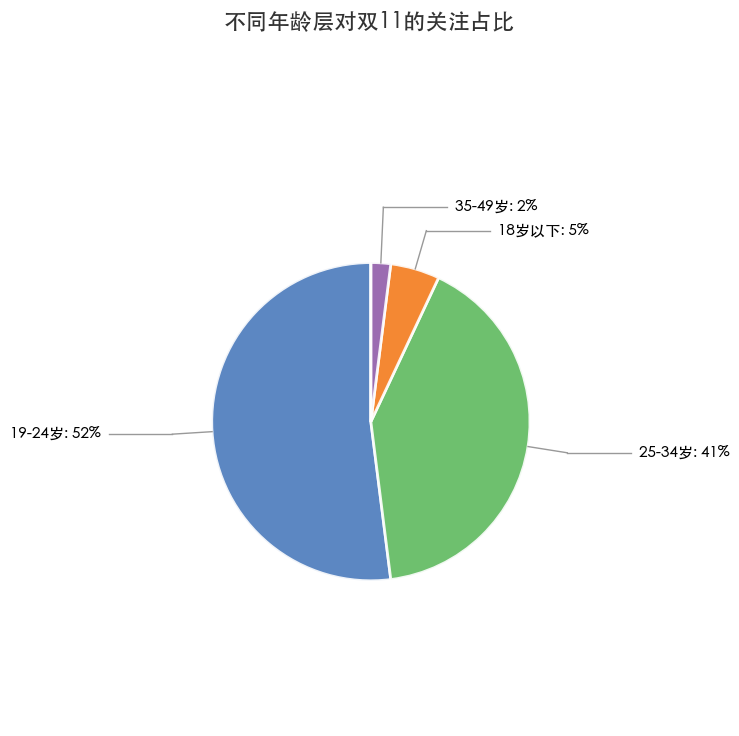

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
age_groups = ["19-24岁", "25-34岁", "18岁以下", "35-49岁", "50岁以上"]
age_percentages = [52, 41, 5, 2, 0]
age_colors = ['#4A7ABC', '#5EB95E', '#F37B1D', '#905CA9', '#E5E5E5']

# 创建画布
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# 绘制美化的饼图
wedges, texts = ax.pie(
    age_percentages,
    labels=None,
    autopct=None,
    startangle=90,
    colors=age_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    pctdistance=0.8,
)

# 为饼图添加阴影效果
for w in wedges:
    w.set_alpha(0.9)
    w.set_zorder(1)

# 设置标题
ax.set_title("不同年龄层对双11的关注占比", fontsize=16, pad=25, 
              fontweight='bold', color='#333333')
ax.axis('equal')  # 保证饼图是圆的

# 优化标签位置计算，使用斜线+水平线样式
label_positions = []

for i, (wedge, group, percent) in enumerate(zip(wedges, age_groups, age_percentages)):
    if percent == 0:  # 跳过0%的部分
        continue
        
    # 获取楔形的角度
    ang = (wedge.theta2 - wedge.theta1)/2. + wedge.theta1
    rad = np.deg2rad(ang)
    y = np.sin(rad)
    x = np.cos(rad)
    
    # 智能调整标签距离
    angle = wedge.theta2 - wedge.theta1
    base_radius = 1.25
    radius = base_radius + max(0, 0.3 - angle/180)
    
    # 计算斜线终点和水平线终点
    line1_length = 0.25
    line2_length = 0.4
    
    line1_end_x = x * (1 + line1_length)
    line1_end_y = y * (1 + line1_length)
    
    if x > 0:  # 右侧标签
        line2_end_x = line1_end_x + line2_length
        line2_end_y = line1_end_y
    else:  # 左侧标签
        line2_end_x = line1_end_x - line2_length
        line2_end_y = line1_end_y
    
    # 检查是否与已有标签重叠
    overlap = False
    label_pos = (line2_end_x, line2_end_y)
    
    for pos in label_positions:
        dist = np.sqrt((label_pos[0] - pos[0])**2 + (label_pos[1] - pos[1])**2)
        if dist < 0.3:
            overlap = True
            if x > 0:  # 右侧标签上移
                line1_end_y += 0.1
                line2_end_y += 0.1
            else:  # 左侧标签下移
                line1_end_y -= 0.1
                line2_end_y -= 0.1
            break
    
    label_positions.append(label_pos)
    
    # 绘制两段式连接线
    ax.plot([x, line1_end_x], [y, line1_end_y], color='#999999', linestyle='-', linewidth=1)
    ax.plot([line1_end_x, line2_end_x], [line1_end_y, line2_end_y], color='#999999', linestyle='-', linewidth=1)
    
    # 添加标签文本
    if x > 0:
        ax.text(line2_end_x + 0.05, line2_end_y, f"{group}: {percent}%", 
                ha='left', va='center', fontsize=11, backgroundcolor='white')
    else:
        ax.text(line2_end_x - 0.05, line2_end_y, f"{group}: {percent}%", 
                ha='right', va='center', fontsize=11, backgroundcolor='white')

# 调整布局
plt.tight_layout(pad=3)

# 保存图表（可选）
# plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()    

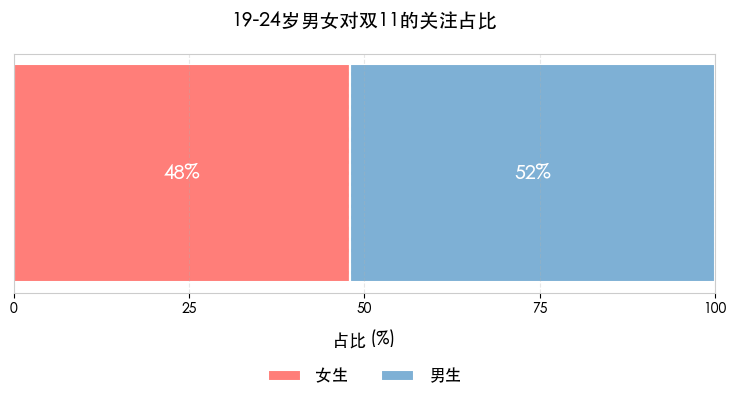

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
genders = ["女生", "男生"]
gender_percents = [48, 52]
gender_colors = ['#FF7E79', '#7EB0D5']

# 创建画布
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

# 绘制美化的水平分段条形图
bar_height = 0.4
ax.barh(0, gender_percents[0], color=gender_colors[0], 
         height=bar_height, edgecolor='white', linewidth=1.5, label=genders[0])
ax.barh(0, gender_percents[1], left=gender_percents[0], color=gender_colors[1], 
         height=bar_height, edgecolor='white', linewidth=1.5, label=genders[1])

# 添加数据标签
ax.text(gender_percents[0]/2, 0, f"{gender_percents[0]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.text(gender_percents[0] + gender_percents[1]/2, 0, f"{gender_percents[1]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')

# 设置条形图样式
ax.set_xlim(0, 100)
ax.set_yticks([])  # 移除y轴
ax.set_xlabel("占比 (%)", fontsize=12, labelpad=10)
ax.set_title("19-24岁男女对双11的关注占比", fontsize=14, pad=20, fontweight='bold')

# 自定义x轴刻度
ax.set_xticks([0, 25, 50, 75, 100])
ax.tick_params(axis='x', which='major', labelsize=10)

# 添加图例
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), 
           ncol=2, frameon=False, fontsize=12)

# 添加网格线
ax.grid(axis='x', linestyle='--', alpha=0.3)

# 添加边框
for spine in ax.spines.values():
    spine.set_color('#cccccc')

# 在分界处添加斜线 - 男女区分线
divider_y = np.linspace(-bar_height/2, bar_height/2, 100)
divider_x = np.ones_like(divider_y) * gender_percents[0]
ax.plot(divider_x, divider_y, color='white', linewidth=1.5, linestyle='--')

# 调整布局
plt.tight_layout(pad=3)

# 保存图表（可选）
# plt.savefig('gender_distribution.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()    

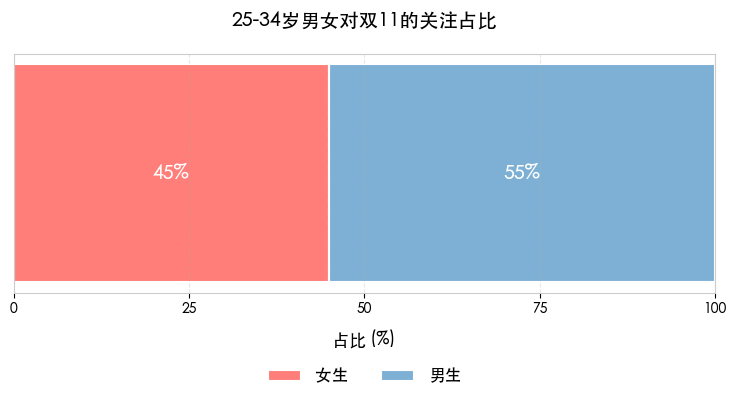

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 数据定义
genders = ["女生", "男生"]
gender_percents = [45, 55]
gender_colors = ['#FF7E79', '#7EB0D5']

# 创建画布
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

# 绘制美化的水平分段条形图
bar_height = 0.4
ax.barh(0, gender_percents[0], color=gender_colors[0], 
         height=bar_height, edgecolor='white', linewidth=1.5, label=genders[0])
ax.barh(0, gender_percents[1], left=gender_percents[0], color=gender_colors[1], 
         height=bar_height, edgecolor='white', linewidth=1.5, label=genders[1])

# 添加数据标签
ax.text(gender_percents[0]/2, 0, f"{gender_percents[0]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.text(gender_percents[0] + gender_percents[1]/2, 0, f"{gender_percents[1]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')

# 设置条形图样式
ax.set_xlim(0, 100)
ax.set_yticks([])  # 移除y轴
ax.set_xlabel("占比 (%)", fontsize=12, labelpad=10)
ax.set_title("25-34岁男女对双11的关注占比", fontsize=14, pad=20, fontweight='bold')

# 自定义x轴刻度
ax.set_xticks([0, 25, 50, 75, 100])
ax.tick_params(axis='x', which='major', labelsize=10)

# 添加图例
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), 
           ncol=2, frameon=False, fontsize=12)

# 添加网格线
ax.grid(axis='x', linestyle='--', alpha=0.3)

# 添加边框
for spine in ax.spines.values():
    spine.set_color('#cccccc')

# 在分界处添加斜线 - 男女区分线
divider_y = np.linspace(-bar_height/2, bar_height/2, 100)
divider_x = np.ones_like(divider_y) * gender_percents[0]
ax.plot(divider_x, divider_y, color='white', linewidth=1.5, linestyle='--')

# 调整布局
plt.tight_layout(pad=3)

# 保存图表（可选）
# plt.savefig('gender_distribution.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()    